# Numerical Methods — Lecture Notes (L1–L7)

Personal study notes on numerical analysis, following the structure of the
course *Metodi Numerici* (chapters 1–7). Every section states the theory
first (definitions, theorems, and where the theorem comes from) and then
gives a small, tested Python/NumPy implementation that illustrates the
result experimentally — the goal is to keep the abstract statement and the
concrete computation next to each other.

## Sources

- **[D]** G. Puppo, *Metodi Numerici*, lecture notes, Sapienza Università di
  Roma. Chapters 1–7 (Strumenti del mestiere; Sistemi lineari; Equazioni e
  sistemi non lineari; Sistemi sovradeterminati; Approssimazione di funzioni
  con polinomi; Approssimazione di derivate e integrali; Calcolo di
  autovalori). Referenced inline as `[D, §x.y]`.
- **[B]** A. Greenbaum and T. P. Chartier, *Numerical Methods: Design,
  Analysis, and Computer Implementation of Algorithms*, Princeton University
  Press, 2012. Referenced inline as `[B, Ch. x]`.
- Further standard references used for definitions/theorems that are
  classical and not specific to either source above:
  - L. N. Trefethen and D. Bau III, *Numerical Linear Algebra*, SIAM, 1997.
  - G. H. Golub and C. F. Van Loan, *Matrix Computations*, 4th ed., Johns
    Hopkins University Press, 2013.
  - A. Quarteroni, R. Sacco, F. Saleri, *Numerical Mathematics*, 2nd ed.,
    Springer, 2007.
  - IEEE Std 754-2019, *IEEE Standard for Floating-Point Arithmetic*.

## Structure

| Section | Topic | Main source |
|---|---|---|
| L1 | Tools of the trade: floating point, norms, condition number, eigenvalues, SVD | [D, Ch. 1] |
| L2 | Linear systems: Gaussian elimination, LU, Jacobi, gradient method | [D, Ch. 2] |
| L3 | Nonlinear equations: Newton's method | [D, Ch. 3] |
| L4 | Overdetermined systems: normal equations, QR, Gram–Schmidt | [D, Ch. 4] |
| L5 | Polynomial approximation: Lagrange interpolation, error, piecewise interpolation | [D, Ch. 5] |
| L6 | Numerical differentiation and integration | [D, Ch. 6] |
| L7 | Eigenvalue computation: power method, inverse power method, QR algorithm | [D, Ch. 7] |

The notebook is a from-scratch, English, rewritten and debugged version of
earlier working notes on these same topics; it does not reproduce the text
of the sources, only their statements of standard results, properly cited.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)

# L1 — Tools of the Trade

*[D, Ch. 1] "Strumenti del mestiere"; [B, Ch. 5, 6, 7.4]*

## L1.1 Floating-point numbers and machine epsilon

**Representation.** In IEEE 754 double precision, a normalized floating
point number is

$$ x = \pm (1 + f) \cdot 2^{e}, \qquad f = \sum_{i=1}^{52} b_i 2^{-i},\ \ b_i\in\{0,1\}, $$

with a 52-bit mantissa and 11-bit exponent `[B, §5.3–5.4]`. Because the
mantissa has finitely many bits, only finitely many reals in any bounded
range are exactly representable; every other real is rounded to the
nearest representable number, `fl(x)`.

**Machine epsilon.** $\varepsilon_{\text{mach}}$ (double precision) is
defined as the distance between $1$ and the next larger representable
number, i.e. the smallest positive $\varepsilon$ such that

$$ \mathrm{fl}(1+\varepsilon) \neq 1 . $$

For IEEE 754 double precision this is $\varepsilon_{\text{mach}} = 2^{-52}
\approx 2.22\times10^{-16}$ `[D, §1.1]`, `[IEEE 754-2019]`.

**Unit roundoff and the fundamental axiom of floating point.** For every
real $x$ within the representable range,

$$ \mathrm{fl}(x) = x(1+\delta), \qquad |\delta| \le u := \tfrac12 \varepsilon_{\text{mach}}, $$

and every elementary floating point operation $\mathrm{op}\in\{+,-,\times,\div\}$
satisfies

$$ \mathrm{fl}(a \ \mathrm{op}\ b) = (a\ \mathrm{op}\ b)(1+\delta), \qquad |\delta|\le u $$

`[B, §5.5–5.6]`, `[Trefethen & Bau, Lecture 13]`. This single axiom is the
starting point of every rounding-error / backward-error analysis used later
(e.g. conditioning in L1.3, stability of Gaussian elimination in L2).

In [2]:
# Empirically compute machine epsilon: smallest eps with fl(1+eps) != 1,
# found by halving until the halved value no longer changes 1.0 in
# floating point arithmetic.
eps = 1.0
while (1.0 + eps / 2.0) != 1.0:
    eps /= 2.0

print(f"empirical machine epsilon      = {eps:.3e}")
print(f"numpy.finfo(float64).eps       = {np.finfo(float).eps:.3e}")
print(f"2**-52                         = {2.0**-52:.3e}")

# fl(1 + eps) != 1  but fl(1 + eps/2) == 1  (eps here is the true machine eps)
print()
print(f"1.0 + eps       == 1.0 ? {(1.0 + eps) == 1.0}")
print(f"1.0 + eps/2.0   == 1.0 ? {(1.0 + eps / 2.0) == 1.0}")

empirical machine epsilon      = 2.220e-16
numpy.finfo(float64).eps       = 2.220e-16
2**-52                         = 2.220e-16

1.0 + eps       == 1.0 ? False
1.0 + eps/2.0   == 1.0 ? True


**Why it matters: catastrophic cancellation.** Subtracting two nearly equal
floating point numbers cancels the leading (correct) digits and amplifies
the relative error of the *rounding*, even though each input was
represented to full relative accuracy $u$. Classic example: evaluate
$g(x) = \sqrt{x+1} - \sqrt{x}$ for large $x$ directly, versus the
mathematically equivalent, cancellation-free form $1/(\sqrt{x+1}+\sqrt{x})$.

In [3]:
def g_naive(x):
    return np.sqrt(x + 1.0) - np.sqrt(x)

def g_stable(x):
    return 1.0 / (np.sqrt(x + 1.0) + np.sqrt(x))

xs = np.array([1e0, 1e4, 1e8, 1e12, 1e15])
for x in xs:
    naive = g_naive(x)
    stable = g_stable(x)
    rel_diff = abs(naive - stable) / abs(stable)
    print(f"x={x:<10.0e}  naive={naive:.10e}  stable={stable:.10e}  rel.diff={rel_diff:.3e}")

x=1e+00       naive=4.1421356237e-01  stable=4.1421356237e-01  rel.diff=1.340e-16
x=1e+04       naive=4.9998750062e-03  stable=4.9998750062e-03  rel.diff=2.130e-13
x=1e+08       naive=5.0000000556e-05  stable=4.9999999875e-05  rel.diff=1.362e-08
x=1e+12       naive=5.0000380725e-07  stable=5.0000000000e-07  rel.diff=7.614e-06
x=1e+15       naive=1.8626451492e-08  stable=1.5811388301e-08  rel.diff=1.780e-01


As $x$ grows, `naive` loses more and more significant digits to
cancellation (the relative difference from the stable formula grows),
even though every individual operation satisfies the $u$-accuracy axiom
above: **the algorithm, not any single operation, is unstable.** This
distinction (accurate operations vs. stable algorithm) is formalized in
`[B, Ch. 6]` and is the reason numerical linear algebra cares about
*algorithm* stability separately from *problem* conditioning (L1.3).

## L1.2 Vector and matrix norms

A norm $\|\cdot\|$ on $\mathbb{R}^n$ satisfies positivity, homogeneity and
the triangle inequality. The most common vector norms are

$$ \|x\|_1=\sum_i|x_i|, \qquad \|x\|_2=\Big(\sum_i x_i^2\Big)^{1/2}, \qquad \|x\|_\infty=\max_i|x_i| . $$

A matrix norm induced by a vector norm is

$$ \|A\| = \max_{x\neq 0} \frac{\|Ax\|}{\|x\|} = \max_{\|x\|=1}\|Ax\| , $$

and every induced norm is *submultiplicative*: $\|AB\|\le \|A\|\,\|B\|$
`[D, §1.4]`, `[B, §7.4.1]`. The Frobenius norm
$\|A\|_F=(\sum_{i,j}a_{ij}^2)^{1/2}$ is a norm but is **not** induced by any
vector norm, although it is still submultiplicative.

In [4]:
rng = np.random.default_rng(0)
A = rng.standard_normal((4, 4))
B = rng.standard_normal((4, 4))

for name, ord_ in [("1-norm", 1), ("2-norm (spectral)", 2), ("inf-norm", np.inf), ("Frobenius", "fro")]:
    lhs = np.linalg.norm(A @ B, ord=ord_)
    rhs = np.linalg.norm(A, ord=ord_) * np.linalg.norm(B, ord=ord_)
    print(f"{name:<20s} ||AB||={lhs:8.4f}   ||A||*||B||={rhs:8.4f}   submultiplicative: {lhs <= rhs + 1e-10}")

1-norm               ||AB||=  4.6571   ||A||*||B||= 10.7923   submultiplicative: True
2-norm (spectral)    ||AB||=  3.5222   ||A||*||B||=  6.1860   submultiplicative: True
inf-norm             ||AB||=  6.2025   ||A||*||B||= 12.0408   submultiplicative: True
Frobenius            ||AB||=  4.2348   ||A||*||B||= 10.1624   submultiplicative: True


## L1.3 Condition number of a matrix

**Definition.** For a nonsingular $A$ and an induced norm,

$$ \operatorname{cond}(A) = \|A\|\,\|A^{-1}\| \ \ (\ge 1). $$

**Theorem (sensitivity of $Ax=b$).** Let $Ax=b$ and $A(x+\delta x)=b+\delta b$
(same $A$, perturbed right-hand side). Then

$$ \frac{\|\delta x\|}{\|x\|} \ \le\ \operatorname{cond}(A)\,\frac{\|\delta b\|}{\|b\|}. $$

*Proof sketch.* $\delta x = A^{-1}\delta b \Rightarrow \|\delta x\|\le
\|A^{-1}\|\|\delta b\|$. Also $\|b\|=\|Ax\|\le\|A\|\|x\| \Rightarrow
\|x\|\ge \|b\|/\|A\|$. Divide the two. $\blacksquare$

An analogous bound holds when $A$ itself is perturbed (to first order,
$\|\delta x\|/\|x\| \lesssim \operatorname{cond}(A)\,\|\delta A\|/\|A\|$).
So $\operatorname{cond}(A)$ is exactly the worst-case amplification factor
between a *relative* perturbation of the data ($b$ or $A$) and the
resulting *relative* perturbation of the solution $x$ — it bounds how
much floating-point rounding in the input can be magnified in the output,
independently of which algorithm is used to solve the system
`[D, §1.5]`, `[B, §7.4.2]`, `[Trefethen & Bau, Lecture 12]`.

**Ill-conditioned example: the Hilbert matrix**, $H^{(n)}_{ij}=1/(i+j-1)$.
It is symmetric positive definite (hence invertible) for every $n$, but
$\operatorname{cond}_2(H^{(n)})$ grows exponentially with $n$ `[D, §2.3]`.

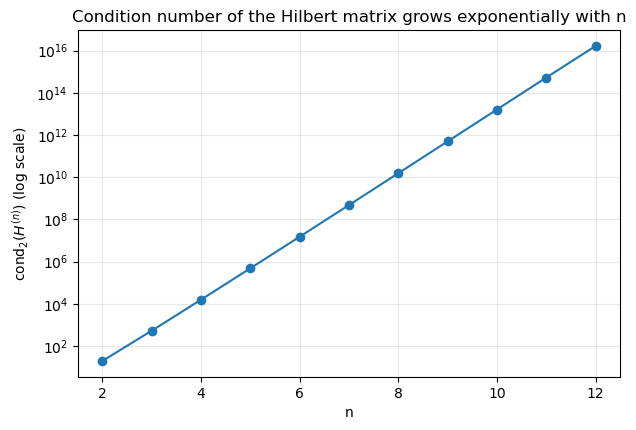

n= 2   cond_2(H) = 1.9281e+01
n= 5   cond_2(H) = 4.7661e+05
n= 8   cond_2(H) = 1.5258e+10
n=11   cond_2(H) = 5.2218e+14


In [5]:
def hilbert(n):
    i = np.arange(1, n + 1).reshape(-1, 1)
    j = np.arange(1, n + 1).reshape(1, -1)
    return 1.0 / (i + j - 1.0)

ns = np.arange(2, 13)
conds = [np.linalg.cond(hilbert(n)) for n in ns]

plt.figure()
plt.semilogy(ns, conds, "o-")
plt.xlabel("n")
plt.ylabel(r"$\mathrm{cond}_2(H^{(n)})$ (log scale)")
plt.title("Condition number of the Hilbert matrix grows exponentially with n")
plt.grid(True, which="both", alpha=0.3)
plt.show()

for n in [2, 5, 8, 11]:
    print(f"n={n:2d}   cond_2(H) = {np.linalg.cond(hilbert(n)):.4e}")

**Verifying the perturbation bound experimentally.** Fix $n=8$, solve
$Hx=b$, perturb $b$ by random noise of relative size $10^{-10}$, and check
that the *observed* relative change in $x$ never exceeds
$\operatorname{cond}(H)\cdot\|\delta b\|/\|b\|$.

In [6]:
n = 8
H = hilbert(n)
x_true = np.ones(n)
b = H @ x_true
condH = np.linalg.cond(H)

rng = np.random.default_rng(1)
rows = []
for trial in range(6):
    db = rng.standard_normal(n)
    db *= 1e-10 * np.linalg.norm(b) / np.linalg.norm(db)  # rescale to relative size 1e-10
    x_pert = np.linalg.solve(H, b + db)
    rel_dx = np.linalg.norm(x_pert - x_true) / np.linalg.norm(x_true)
    rel_db = np.linalg.norm(db) / np.linalg.norm(b)
    bound = condH * rel_db
    rows.append((rel_db, rel_dx, bound, rel_dx <= bound))

print(f"{'||db||/||b||':>14}  {'||dx||/||x||':>14}  {'cond(H)*rel_db':>16}  bound holds")
for rel_db, rel_dx, bound, ok in rows:
    print(f"{rel_db:14.3e}  {rel_dx:14.3e}  {bound:16.3e}  {ok}")

  ||db||/||b||    ||dx||/||x||    cond(H)*rel_db  bound holds
     1.000e-10       2.176e-02         1.526e+00  True
     1.000e-10       6.741e-01         1.526e+00  True
     1.000e-10       4.977e-01         1.526e+00  True
     1.000e-10       3.909e-01         1.526e+00  True
     1.000e-10       3.904e-01         1.526e+00  True
     1.000e-10       1.066e-01         1.526e+00  True


## L1.4 Eigenvalues and eigenvectors

**Definition.** $\lambda\in\mathbb{C}$ is an eigenvalue of $A\in\mathbb{R}^{n\times n}$
with eigenvector $v\neq 0$ if $Av=\lambda v$, i.e. $\det(A-\lambda I)=0$
`[D, §1.6]`, `[B, App. A.8]`.

**Spectral theorem (symmetric case).** If $A=A^{T}$, all eigenvalues of
$A$ are real and $A$ admits an orthonormal basis of eigenvectors, i.e.
$A = Q\Lambda Q^{T}$ with $Q$ orthogonal and $\Lambda$ real diagonal
`[B, App. A.8]`.

This section only states the definitions needed later; the *algorithms*
that compute eigenpairs numerically (power method, inverse iteration, QR
algorithm) are developed in **L7**, since they require material from L2
(linear systems / factorizations) first.

## L1.5 Singular Value Decomposition (SVD)

**Theorem (existence of the SVD).** Every $A\in\mathbb{R}^{m\times n}$ can
be written as

$$ A = U\Sigma V^{T}, $$

with $U\in\mathbb{R}^{m\times m}$, $V\in\mathbb{R}^{n\times n}$ orthogonal
and $\Sigma\in\mathbb{R}^{m\times n}$ diagonal with non-negative entries
$\sigma_1\ge\sigma_2\ge\dots\ge0$ (the singular values). The $\sigma_i$ are
the square roots of the eigenvalues of $A^{T}A$ `[D, §1.7]`,
`[Golub & Van Loan, Ch. 2]`.

**Theorem (Eckart–Young).** Among all matrices of rank $\le k$, the
truncated SVD $A_k=\sum_{i=1}^{k}\sigma_i u_i v_i^{T}$ minimizes both
$\|A-A_k\|_2=\sigma_{k+1}$ and $\|A-A_k\|_F=\big(\sum_{i>k}\sigma_i^2\big)^{1/2}$
`[D, §1.7.2]`, `[Trefethen & Bau, Lecture 5]`. This is the mathematical
justification for using the SVD for dimensionality reduction / low-rank
approximation.

In [7]:
def svd_low_rank_approx(X, k):
    # Best rank-k approximation of X in the Frobenius/2-norm (Eckart-Young).
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    S_k = np.zeros_like(S)
    S_k[:k] = S[:k]
    return U @ np.diag(S_k) @ Vt, S

rng = np.random.default_rng(2)
# a matrix that is *exactly* rank 2 plus small noise
true_rank2 = rng.standard_normal((30, 2)) @ rng.standard_normal((2, 6))
X = true_rank2 + 0.01 * rng.standard_normal((30, 6))

errors_frob, errors_2 = [], []
_, S = svd_low_rank_approx(X, 1)
ks = range(0, 6)
for k in ks:
    Xk, _ = svd_low_rank_approx(X, k)
    Xc = X - X.mean(axis=0)
    errors_frob.append(np.linalg.norm(Xc - Xk, "fro"))
    errors_2.append(np.linalg.norm(Xc - Xk, 2))

predicted_frob = [np.sqrt(np.sum(S[k:] ** 2)) for k in ks]
predicted_2 = [S[k] if k < len(S) else 0.0 for k in ks]

print(f"{'k':>2}  {'||X-Xk||_F':>12}  {'sqrt(sum s_i^2, i>k)':>20}  {'||X-Xk||_2':>12}  {'s_{k+1}':>10}")
for k, ef, pf, e2, p2 in zip(ks, errors_frob, predicted_frob, errors_2, predicted_2):
    print(f"{k:2d}  {ef:12.6f}  {pf:20.6f}  {e2:12.6f}  {p2:10.6f}")

 k    ||X-Xk||_F  sqrt(sum s_i^2, i>k)    ||X-Xk||_2     s_{k+1}
 0     20.780590             20.780590     19.340075   19.340075
 1      7.602264              7.602264      7.601573    7.601573
 2      0.102540              0.102540      0.060861    0.060861
 3      0.082525              0.082525      0.051930    0.051930
 4      0.064137              0.064137      0.048060    0.048060
 5      0.042471              0.042471      0.042471    0.042471


The reconstruction error matches the Eckart–Young prediction to numerical
precision, and both errors collapse to (near) zero once $k\ge2$ — exactly
the true rank of the noiseless signal used to build `X`.

# L2 — Linear Systems

*[D, Ch. 2] "Sistemi lineari"; [B, Ch. 7, §12.2]*

## L2.1 Gaussian elimination

Gaussian elimination reduces $Ax=b$ to an equivalent upper-triangular
system $Ux=c$ by successively eliminating the entries below the pivot with
row operations $R_i \leftarrow R_i - m_{ij}R_j$,
$m_{ij}=a_{ij}/a_{jj}$, then solves $Ux=c$ by back substitution. Cost is
$O(\tfrac{2}{3}n^3)$ flops for elimination `[D, §2.2]`, `[B, §7.2.1]`.

In [8]:
def gauss_elimination(A, b):
    # Solve Ax = b by Gaussian elimination with back substitution (no pivoting).
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)

    # forward elimination
    for j in range(n - 1):
        for i in range(j + 1, n):
            m = A[i, j] / A[j, j]
            A[i, j:] -= m * A[j, j:]
            b[i] -= m * b[j]

    # back substitution
    x = np.zeros(n)
    for i in reversed(range(n)):
        x[i] = (b[i] - A[i, i + 1:] @ x[i + 1:]) / A[i, i]
    return x

A = np.array([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)

x = gauss_elimination(A, b)
print("x        =", x)
print("np.linalg.solve =", np.linalg.solve(A, b))
print("residual ||Ax-b||_2 =", np.linalg.norm(A @ x - b))

x        = [ 2.  3. -1.]
np.linalg.solve = [ 2.  3. -1.]
residual ||Ax-b||_2 = 0.0


## L2.2 LU factorization

**Theorem.** If all leading principal minors of $A$ are nonzero, Gaussian
elimination without pivoting produces a unique factorization $A=LU$ with
$L$ unit lower triangular and $U$ upper triangular; the multipliers
$m_{ij}$ above are exactly the sub-diagonal entries of $L$
`[D, §2.3]`, `[B, §7.2.2]`.

In [9]:
def lu_no_pivoting(A):
    n = A.shape[0]
    L = np.eye(n)
    U = A.astype(float).copy()
    for j in range(n - 1):
        for i in range(j + 1, n):
            L[i, j] = U[i, j] / U[j, j]
            U[i, j:] -= L[i, j] * U[j, j:]
    return L, U

A = np.array([[2, 3, 1], [4, 7, 2], [6, 9, 5]], dtype=float)
L, U = lu_no_pivoting(A)
print("L =\n", L)
print("U =\n", U)
print("||LU - A|| =", np.linalg.norm(L @ U - A))

L =
 [[1. 0. 0.]
 [2. 1. 0.]
 [3. 0. 1.]]
U =
 [[2. 3. 1.]
 [0. 1. 0.]
 [0. 0. 2.]]
||LU - A|| = 0.0


**Ill-conditioning shows up in the factorization too.** Repeat the LU
factorization for the Hilbert matrices of L1.3 and plot the residual
$\|H^{(n)} - LU\|$ against $n$: because $\operatorname{cond}(H^{(n)})$
explodes, the *floating point* factorization increasingly disagrees with
the exact one, even though the algorithm is doing exactly what it should.

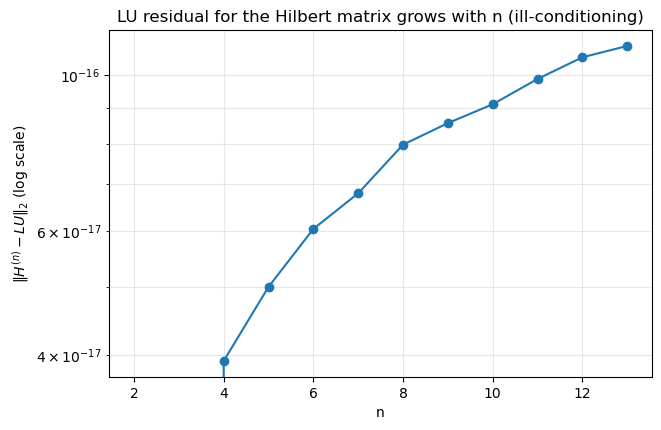

In [10]:
ns = np.arange(2, 14)
residuals = []
for n in ns:
    H = hilbert(n)
    L, U = lu_no_pivoting(H)
    residuals.append(np.linalg.norm(H - L @ U))

plt.figure()
plt.semilogy(ns, residuals, "o-")
plt.xlabel("n")
plt.ylabel(r"$\|H^{(n)} - LU\|_2$ (log scale)")
plt.title("LU residual for the Hilbert matrix grows with n (ill-conditioning)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## L2.3 Simple iterative methods — Jacobi

Split $A = D - E$ with $D=\operatorname{diag}(A)$. The Jacobi iteration is

$$ x^{(k+1)} = D^{-1}\big(b + E x^{(k)}\big) = D^{-1}\big(b - (A-D)x^{(k)}\big). $$

**Theorem.** The iteration converges for any $x^{(0)}$ iff the spectral
radius of the iteration matrix $D^{-1}(A-D)$ is $<1$. A convenient
*sufficient* condition is that $A$ be strictly diagonally dominant by rows:
$|a_{ii}| > \sum_{j\neq i}|a_{ij}|$ for every $i$ `[D, §2.5.1]`,
`[B, §12.2]`.

diagonally dominant: True
solution: [ 1. -2.  1.]
iterations to convergence: 25


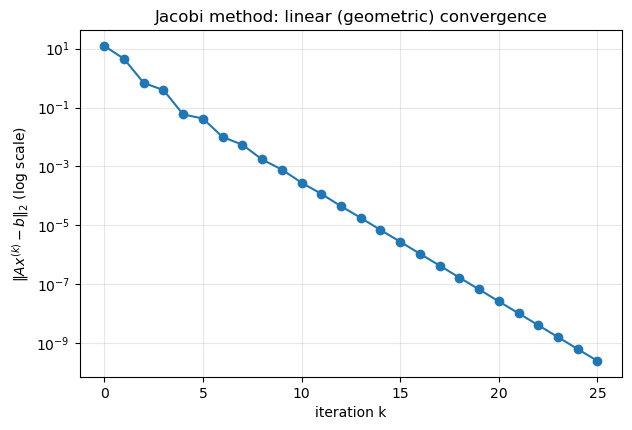

In [11]:
def is_diagonally_dominant(A):
    A = np.asarray(A, dtype=float)
    for i in range(len(A)):
        if abs(A[i, i]) <= np.sum(np.abs(A[i])) - abs(A[i, i]):
            return False
    return True

def jacobi(A, b, x0, tol=1e-10, max_iter=200):
    D = np.diag(A)
    E = A - np.diag(D)
    x = x0.copy()
    history = [x.copy()]
    for _ in range(max_iter):
        x_new = (b - E @ x) / D
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x, np.inf) < tol:
            x = x_new
            break
        x = x_new
    return x, np.array(history)

A = np.array([[10, 2, 1], [1, 5, 1], [2, 3, 10]], dtype=float)
b = np.array([7, -8, 6], dtype=float)
print("diagonally dominant:", is_diagonally_dominant(A))

x_exact = np.linalg.solve(A, b)
x, hist = jacobi(A, b, np.zeros(3))
residuals = [np.linalg.norm(A @ xi - b) for xi in hist]

print("solution:", x)
print("iterations to convergence:", len(hist) - 1)

plt.figure()
plt.semilogy(residuals, "o-")
plt.xlabel("iteration k")
plt.ylabel(r"$\|Ax^{(k)}-b\|_2$ (log scale)")
plt.title("Jacobi method: linear (geometric) convergence")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## L2.4 Gradient (steepest descent) method

For $A$ symmetric positive definite, $Ax=b$ is equivalent to minimizing
the quadratic functional

$$ \varphi(x) = \tfrac12 x^{T}Ax - b^{T}x, \qquad \nabla\varphi(x) = Ax - b = -r(x), $$

where $r(x)=b-Ax$ is the residual. **Steepest descent** moves along
$-\nabla\varphi = r^{(k)}$ with the exact line-search step that minimizes
$\varphi$ along that direction:

$$ x^{(k+1)} = x^{(k)} + \alpha_k r^{(k)}, \qquad
   \alpha_k = \frac{{r^{(k)}}^{T} r^{(k)}}{{r^{(k)}}^{T} A\, r^{(k)}} $$

`[D, §2.6, §2.6.1]`, `[B, §12.2.4]` (steepest descent is the k=1 building
block for the conjugate gradient method described there). Convergence rate
depends on $\operatorname{cond}(A)$: an ill-conditioned $A$ produces a
characteristic zig-zag path and slow convergence.

solution: [0.202703 1.959459]  iterations: 17  cond(A)= 3.080816084754807


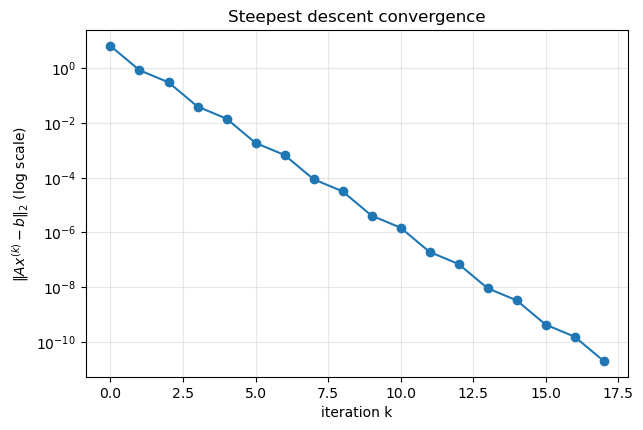

In [12]:
def gradient_method(A, b, x0, tol=1e-10, max_iter=500):
    x = x0.copy()
    history = [x.copy()]
    for _ in range(max_iter):
        r = b - A @ x
        if np.linalg.norm(r) < tol:
            break
        alpha = (r @ r) / (r @ A @ r)
        x = x + alpha * r
        history.append(x.copy())
    return x, np.array(history)

A = np.array([[3.0, 0.2], [0.2, 1.0]])
b = np.array([1.0, 2.0])
x_exact = np.linalg.solve(A, b)

x, hist = gradient_method(A, b, np.array([-2.0, 3.0]))
residuals = [np.linalg.norm(A @ xi - b) for xi in hist]
print("solution:", x, " iterations:", len(hist) - 1, " cond(A)=", np.linalg.cond(A))

plt.figure()
plt.semilogy(residuals, "o-")
plt.xlabel("iteration k")
plt.ylabel(r"$\|Ax^{(k)}-b\|_2$ (log scale)")
plt.title("Steepest descent convergence")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# L3 — Nonlinear Equations

*[D, Ch. 3] "Equazioni e sistemi non lineari"; [B, Ch. 4]*

## L3.1 Newton's method

Given $f\in C^2$ and a current iterate $x_k$, Taylor's theorem gives
$0=f(x^\*)=f(x_k)+f'(x_k)(x^\*-x_k)+O((x^\*-x_k)^2)$. Dropping the
quadratic remainder and solving for $x^\*$ gives the update

$$ x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)} $$

`[D, §3.2.1]`, `[B, §4.2–4.3]`.

**Theorem (local quadratic convergence).** If $f\in C^2$ near a simple
root $x^\*$ (i.e. $f'(x^\*)\neq0$) and $x_0$ is close enough to $x^\*$,
then $x_k\to x^\*$ and

$$ |x_{k+1}-x^\*| \le \frac{M}{2|f'(x^\*)|}\,|x_k-x^\*|^2 = C\,|x_k-x^\*|^2, $$

with $M=\max|f''|$ nearby — the number of correct digits roughly doubles
every iteration `[B, §4.3]`, `[D, §3.2.1]`.

Stopping criterion used below: stop when $|f(x_k)| < \text{tol}\cdot|f(x_0)|$
(a *relative* test against the residual, robust to poor scaling of $f$).

In [13]:
def newton_method(f, df, x0, tol=1e-12, max_iter=100):
    x = x0
    f0 = f(x0)
    trace = [x]
    for _ in range(max_iter):
        fx = f(x)
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError("f'(x) vanished at x = %r" % x)
        x_new = x - fx / dfx
        trace.append(x_new)
        if abs(fx) < tol * abs(f0):
            return x_new, trace
        x = x_new
    return x, trace

f = lambda x: x**3 - 2 * x - 5
df = lambda x: 3 * x**2 - 2

root, trace = newton_method(f, df, x0=2.0)
print("root =", root, "   f(root) =", f(root))

x_star = root
print(f"\n{'k':>2}  {'x_k':>18}  {'|x_k - x*|':>14}  {'ratio |e_k|/|e_{k-1}|^2':>24}")
prev_err = None
for k, xk in enumerate(trace):
    err = abs(xk - x_star)
    ratio = "" if prev_err in (None, 0) or err == 0 else f"{err / prev_err**2:.4f}"
    print(f"{k:2d}  {xk:18.14f}  {err:14.3e}  {ratio:>24}")
    prev_err = err

root = 2.0945514815423265    f(root) = -8.881784197001252e-16

 k                 x_k      |x_k - x*|   ratio |e_k|/|e_{k-1}|^2
 0    2.00000000000000       9.455e-02                          
 1    2.10000000000000       5.449e-03                    0.6095
 2    2.09456812110419       1.664e-05                    0.5605
 3    2.09455148169820       1.559e-10                    0.5630
 4    2.09455148154233       0.000e+00                          
 5    2.09455148154233       0.000e+00                          


The error roughly squares at every step (once close to the root) and the
ratio $|e_k|/|e_{k-1}|^2$ settles to a near-constant value, exactly as
predicted by the quadratic-convergence theorem.

*Remark.* Newton's method needs a good starting guess and $f'(x_k)\neq0$;
a more robust but linearly-convergent alternative when only a bracketing
interval $[a,b]$ with $f(a)f(b)<0$ is known is **bisection**
`[D, §3.1]`, `[B, §4.1]`, often used to get near the root before switching
to Newton.

# L4 — Overdetermined Systems (Least Squares)

*[D, Ch. 4] "Sistemi sovradeterminati"; [B, §7.6], [Trefethen & Bau, Lecture 8]*

## L4.1 Normal equations

For $A\in\mathbb{R}^{m\times n}$, $m>n$, full column rank, the least
squares problem $\min_x\|Ax-b\|_2$ has the unique solution of the
**normal equations**

$$ A^{T}A\,x = A^{T}b $$

`[D, §4.1]`, `[B, §7.6.1]`. This is elegant but numerically delicate:
forming $A^TA$ **squares the condition number**,
$\operatorname{cond}_2(A^{T}A)=\operatorname{cond}_2(A)^2$ (direct
consequence of the SVD, L1.5), so any perturbation is amplified far more
than necessary — a direct application of the sensitivity bound of L1.3.
This motivates solving the problem via QR instead (L4.2–L4.3), which never
forms $A^TA$.

In [14]:
rng = np.random.default_rng(3)
m, n = 8, 4
A = rng.standard_normal((m, n))
A[:, -1] = A[:, 0] + 1e-6 * rng.standard_normal(m)   # nearly collinear columns -> ill-conditioned

cond_A = np.linalg.cond(A)
cond_AtA = np.linalg.cond(A.T @ A)
print(f"cond_2(A)    = {cond_A:.4e}")
print(f"cond_2(A^T A)= {cond_AtA:.4e}")
print(f"cond_2(A)^2  = {cond_A**2:.4e}   (matches cond(A^T A))")

cond_2(A)    = 2.1614e+06
cond_2(A^T A)= 4.6703e+12
cond_2(A)^2  = 4.6718e+12   (matches cond(A^T A))


## L4.2 QR factorization via Gram–Schmidt

Every $A\in\mathbb{R}^{m\times n}$ with full column rank has a **thin QR
factorization** $A=QR$, $Q\in\mathbb{R}^{m\times n}$ with orthonormal
columns, $R$ upper triangular with positive diagonal. Classical
Gram–Schmidt builds it by orthogonalizing each column against all previous
$Q$-columns; **modified** Gram–Schmidt reorders the same arithmetic to
subtract projections incrementally, which is significantly more stable in
floating point (loses less orthogonality) `[D, §4.3.1]`,
`[B, App. A.4]`, `[Trefethen & Bau, Lecture 8]`.

In [15]:
def modified_gram_schmidt(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    V = A.astype(float).copy()
    for j in range(n):
        R[j, j] = np.linalg.norm(V[:, j])
        Q[:, j] = V[:, j] / R[j, j]
        for k in range(j + 1, n):
            R[j, k] = Q[:, j] @ V[:, k]
            V[:, k] -= R[j, k] * Q[:, j]
    return Q, R

def classical_gram_schmidt(A):
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].astype(float).copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ A[:, j]
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

A = np.array([[1, 1, 1], [1, 0, 1], [0, 0, 1]], dtype=float)
Q, R = modified_gram_schmidt(A)
print("Q =\n", Q)
print("R =\n", R)
print("||Q^T Q - I|| =", np.linalg.norm(Q.T @ Q - np.eye(3)))
print("||QR - A||    =", np.linalg.norm(Q @ R - A))

Q =
 [[ 0.707107  0.707107  0.      ]
 [ 0.707107 -0.707107  0.      ]
 [ 0.        0.        1.      ]]
R =
 [[1.414214 0.707107 1.414214]
 [0.       0.707107 0.      ]
 [0.       0.       1.      ]]
||Q^T Q - I|| = 6.334706989936071e-16
||QR - A||    = 2.237114317075737e-17


In [16]:
# Classical vs modified Gram-Schmidt: loss of orthogonality on a
# nearly rank-deficient (ill-conditioned) matrix.
rng = np.random.default_rng(4)
eps_col = 1e-8
A_bad = np.zeros((4, 3))
A_bad[:, 0] = [1, eps_col, 0, 0]
A_bad[:, 1] = [1, 0, eps_col, 0]
A_bad[:, 2] = [1, 0, 0, eps_col]

Qc, _ = classical_gram_schmidt(A_bad)
Qm, _ = modified_gram_schmidt(A_bad)

print(f"cond_2(A_bad)                        = {np.linalg.cond(A_bad):.3e}")
print(f"||Q_classical^T Q_classical - I||_F   = {np.linalg.norm(Qc.T @ Qc - np.eye(3)):.3e}")
print(f"||Q_modified^T  Q_modified  - I||_F   = {np.linalg.norm(Qm.T @ Qm - np.eye(3)):.3e}")

cond_2(A_bad)                        = 1.732e+08
||Q_classical^T Q_classical - I||_F   = 7.071e-01
||Q_modified^T  Q_modified  - I||_F   = 1.155e-08


Both variants are mathematically identical formulas, yet modified
Gram–Schmidt keeps the computed $Q$ far closer to orthogonal on
ill-conditioned input — a concrete instance of *algorithm stability*
(L1.1) mattering independently of the exact-arithmetic theory.

## L4.3 Least squares via QR

Since $Q$ has orthonormal columns, $\|Ax-b\|_2=\|QRx-b\|_2=\|Rx-Q^Tb\|_2$
(using $\|Qy\|_2=\|y\|_2$ and completing $Q$ to a full orthogonal basis),
so the least-squares solution solves the *triangular* system
$Rx=Q^{T}b$ `[D, §4.2]`, `[B, §7.6.2]` — no explicit inverse, no $A^TA$.

In [17]:
rng = np.random.default_rng(5)
m, n = 10, 3
A = rng.standard_normal((m, n))
x_true = np.array([1.0, -2.0, 0.5])
b = A @ x_true + 0.01 * rng.standard_normal(m)

Q, R = modified_gram_schmidt(A)
x_qr = np.linalg.solve(R, Q.T @ b)
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]

print("x_qr     =", x_qr)
print("x_lstsq  =", x_lstsq)
print("||x_qr - x_lstsq|| =", np.linalg.norm(x_qr - x_lstsq))

x_qr     = [ 1.002902 -1.997917  0.503852]
x_lstsq  = [ 1.002902 -1.997917  0.503852]
||x_qr - x_lstsq|| = 4.002966042486721e-16


# L5 — Polynomial Approximation

*[D, Ch. 5] "Approssimazione di funzioni con polinomi"; [B, Ch. 8]*

## L5.1 Lagrange interpolation

**Theorem (existence and uniqueness).** Given $n+1$ distinct nodes
$x_0,\dots,x_n$ and values $y_i=f(x_i)$, there is a unique polynomial
$P_n$ of degree $\le n$ with $P_n(x_i)=y_i$ for all $i$ `[D, §5.1]`,
`[B, §8.1]` (uniqueness follows from the fact that a nonzero degree-$\le n$
polynomial has at most $n$ roots).

The **Lagrange form** builds $P_n$ directly without solving a linear
system, using the cardinal basis $L_j(x_i)=\delta_{ij}$:

$$ L_j(x) = \prod_{i\neq j}\frac{x-x_i}{x_j-x_i}, \qquad
   P_n(x) = \sum_{j=0}^{n} y_j\, L_j(x) $$

`[D, §5.2]`, `[B, §8.2]`.

In [18]:
def lagrange_interpolate(x_nodes, y_nodes, z):
    # Evaluate the Lagrange interpolating polynomial at point(s) z.
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    z = np.atleast_1d(np.asarray(z, dtype=float))
    n = len(x_nodes) - 1

    P = np.zeros_like(z)
    for j in range(n + 1):
        Lj = np.ones_like(z)
        for i in range(n + 1):
            if i != j:
                Lj *= (z - x_nodes[i]) / (x_nodes[j] - x_nodes[i])
        P += y_nodes[j] * Lj
    return P if P.size > 1 else P[0]

f = np.sin
a, b, n = 0.0, np.pi, 5
x_nodes = np.linspace(a, b, n + 1)
y_nodes = f(x_nodes)

z = np.pi / 2
print(f"P_{n}({z:.4f}) = {lagrange_interpolate(x_nodes, y_nodes, z):.10f}")
print(f"f({z:.4f})   = {f(z):.10f}   (node coincides with a sample point here)")

P_5(1.5708) = 0.9997175479
f(1.5708)   = 1.0000000000   (node coincides with a sample point here)


## L5.2 Error in polynomial interpolation

**Theorem.** If $f\in C^{n+1}[a,b]$, for every $z\in[a,b]$ there is
$\xi=\xi(z)\in(a,b)$ with

$$ f(z) - P_n(z) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\prod_{i=0}^{n}(z-x_i) $$

`[D, §5.3]`, `[B, §8.4]`. Two consequences used constantly in practice:
the error is exactly zero at the nodes (the product vanishes there), and
for equispaced nodes on a fixed interval the error can *grow* with $n$ for
some functions (Runge phenomenon), because $\max|\prod(z-x_i)|$ grows
faster than $f^{(n+1)}$ shrinks — this is why L5.3 introduces piecewise
interpolation instead of raising the single polynomial's degree
indefinitely.

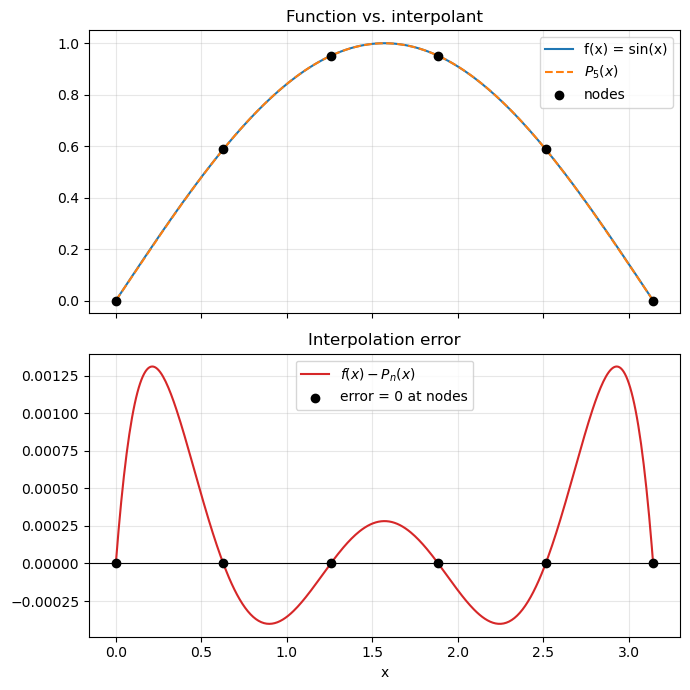

In [19]:
def interpolation_error(f, x_nodes, y_nodes, z):
    return f(z) - lagrange_interpolate(x_nodes, y_nodes, z)

z_plot = np.linspace(a, b, 400)
err = interpolation_error(f, x_nodes, y_nodes, z_plot)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
ax1.plot(z_plot, f(z_plot), label="f(x) = sin(x)")
ax1.plot(z_plot, lagrange_interpolate(x_nodes, y_nodes, z_plot), "--", label=f"$P_{n}(x)$")
ax1.scatter(x_nodes, y_nodes, color="k", zorder=5, label="nodes")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_title("Function vs. interpolant")

ax2.plot(z_plot, err, color="tab:red", label=r"$f(x)-P_n(x)$")
ax2.axhline(0, color="k", lw=0.8)
ax2.scatter(x_nodes, np.zeros(n + 1), color="k", zorder=5, label="error = 0 at nodes")
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_title("Interpolation error")
ax2.set_xlabel("x")
plt.tight_layout()
plt.show()

## L5.3 Composite (piecewise linear) interpolation

Instead of a single high-degree polynomial, split $[a,b]$ into $n$
subintervals of width $h=(b-a)/n$ and interpolate *linearly* on each
subinterval. On $[x_j,x_{j+1}]$,

$$ Q(z) = y_j(1-t) + y_{j+1}t, \qquad t=\frac{z-x_j}{h}, $$

with error $|f(z)-Q(z)|\le \tfrac{h^2}{8}\max|f''|$ on each subinterval
`[D, §5.5]`, `[B, §8.6]` — the error is controlled by refining $h$, rather
than by raising the polynomial degree (avoiding the Runge-phenomenon risk
of L5.2).

In [20]:
def piecewise_linear_interpolate(x_nodes, y_nodes, z):
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    j = np.searchsorted(x_nodes, z) - 1
    j = np.clip(j, 0, len(x_nodes) - 2)
    t = (z - x_nodes[j]) / (x_nodes[j + 1] - x_nodes[j])
    return y_nodes[j] * (1 - t) + y_nodes[j + 1] * t

n_pw = 5
x_pw = np.linspace(a, b, n_pw + 1)
y_pw = f(x_pw)
z_test = np.pi / 2
Q = piecewise_linear_interpolate(x_pw, y_pw, z_test)
print(f"piecewise-linear Q({z_test:.4f}) = {Q:.6f}")
print(f"exact f({z_test:.4f})           = {f(z_test):.6f}")

piecewise-linear Q(1.5708) = 0.951057
exact f(1.5708)           = 1.000000


# L6 — Numerical Differentiation and Integration

*[D, Ch. 6] "Approssimazione di derivate e integrali"; [B, Ch. 9, §10.1]*

## L6.1 Numerical differentiation

The **central difference** formula follows from subtracting the Taylor
expansions of $f(x\pm h)$:

$$ f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}, \qquad
   \text{truncation error} = -\frac{h^2}{6}f'''(\xi) = O(h^2) $$

`[D, §6.1]`, `[B, Ch. 9]`. In *exact* arithmetic, shrinking $h$ always
reduces the error. In *floating point*, evaluating $f(x+h)-f(x-h)$ suffers
catastrophic cancellation (L1.1) of size $O(u|f(x)|/h)$ once $h$ is small,
so the **total** error is

$$ \text{truncation } O(h^2) \ + \ \text{rounding } O(u/h), $$

which is minimized at $h^\*\sim u^{1/3}$ — floating point precision
directly limits how accurate a numerical derivative can be, no matter how
small $h$ is chosen. This is the differentiation-specific instance of the
$\varepsilon_{\text{mach}}$ discussion opened in L1.1.

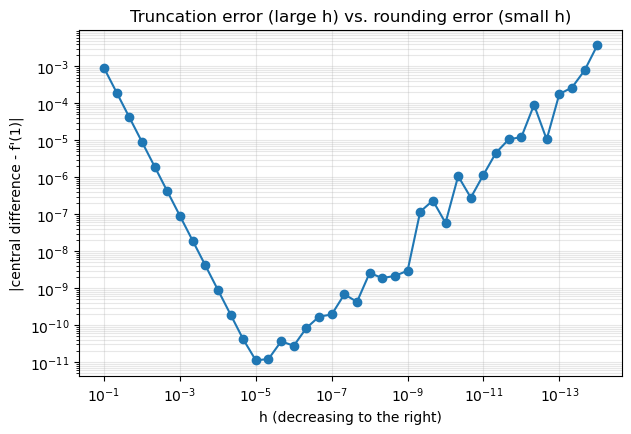

empirically best h ~ 1.000e-05   (theory predicts h* ~ eps_mach^(1/3) = 6.055e-06)


In [21]:
def central_difference(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

f = np.sin
df_exact = np.cos(1.0)
hs = np.logspace(-1, -14, 40)
errors = [abs(central_difference(f, 1.0, h) - df_exact) for h in hs]

plt.figure()
plt.loglog(hs, errors, "o-")
plt.gca().invert_xaxis()
plt.xlabel("h (decreasing to the right)")
plt.ylabel("|central difference - f'(1)|")
plt.title("Truncation error (large h) vs. rounding error (small h)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

h_star = min(zip(hs, errors), key=lambda t: t[1])
print(f"empirically best h ~ {h_star[0]:.3e}   (theory predicts h* ~ eps_mach^(1/3) = {np.finfo(float).eps**(1/3):.3e})")

The V-shape confirms the trade-off exactly: error decreases like $h^2$
on the left, then rounding takes over and error grows like $1/h$ on the
right, with the minimum near the value predicted by the theory.

## L6.2 Numerical integration — Newton–Cotes formulas

Approximate $\int_a^b f$ by integrating the interpolating polynomial
through the nodes exactly. The **composite trapezoidal rule** ($n=1$
piecewise) has error $O(h^2)$; **composite Simpson's rule** (piecewise
quadratic) has error $O(h^4)$ `[D, §6.2, §6.2.1]`, `[B, §10.1]`:

$$
\int_a^b f \approx \frac{h}{2}\Big(f(x_0)+2\sum_{i=1}^{n-1}f(x_i)+f(x_n)\Big) \quad \text{(trapezoidal)}
$$

$$
\int_a^b f \approx \frac{h}{3}\Big(f(x_0)+4\!\!\sum_{i\ \text{odd}}\!\!f(x_i)+2\!\!\sum_{i\ \text{even},\,i\neq0,n}\!\!f(x_i)+f(x_n)\Big) \quad \text{(Simpson, $n$ even)}
$$

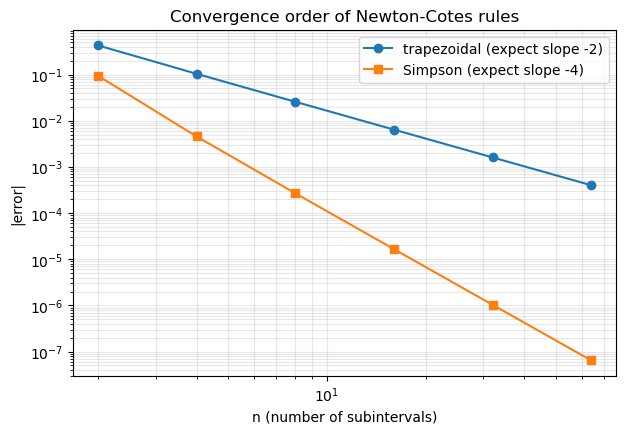

observed trapezoidal order  ~ 2.01  (theory: 2)
observed Simpson order      ~ 4.08  (theory: 4)


In [22]:
def composite_trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])

def composite_simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("Simpson's rule needs an even number of subintervals")
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h / 3 * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum())

f = np.sin
a, b = 0.0, np.pi
exact = 2.0  # integral of sin over [0, pi]

ns = [2, 4, 8, 16, 32, 64]
trap_err = [abs(composite_trapezoidal(f, a, b, n) - exact) for n in ns]
simp_err = [abs(composite_simpson(f, a, b, n) - exact) for n in ns]

plt.figure()
plt.loglog(ns, trap_err, "o-", label="trapezoidal (expect slope -2)")
plt.loglog(ns, simp_err, "s-", label="Simpson (expect slope -4)")
plt.xlabel("n (number of subintervals)")
plt.ylabel("|error|")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.title("Convergence order of Newton-Cotes rules")
plt.show()

import numpy as _np
p_trap = _np.polyfit(_np.log(ns), _np.log(trap_err), 1)[0]
p_simp = _np.polyfit(_np.log(ns), _np.log(simp_err), 1)[0]
print(f"observed trapezoidal order  ~ {-p_trap:.2f}  (theory: 2)")
print(f"observed Simpson order      ~ {-p_simp:.2f}  (theory: 4)")

# L7 — Eigenvalue Computation

*[D, Ch. 7] "Calcolo di autovalori"; [B, §12.1]*

## L7.1 Power method

Given $A$ with eigenvalues $|\lambda_1|>|\lambda_2|\ge\dots$ and a
corresponding eigenvector basis, write $x^{(0)}=\sum_i c_i v_i$ with
$c_1\neq0$. Then

$$ A^{k}x^{(0)} = \lambda_1^{k}\Big(c_1v_1 + \sum_{i>1}c_i\big(\lambda_i/\lambda_1\big)^{k}v_i\Big) \ \xrightarrow[k\to\infty]{} \ \lambda_1^k c_1 v_1, $$

so normalizing $x^{(k)}=A^kx^{(0)}/\|A^kx^{(0)}\|$ converges to (a unit
multiple of) $v_1$, and the Rayleigh quotient $x^{(k)T}Ax^{(k)}\to\lambda_1$,
at **linear rate** governed by $|\lambda_2/\lambda_1|$ `[D, §7.1]`,
`[B, §12.1.1]`.

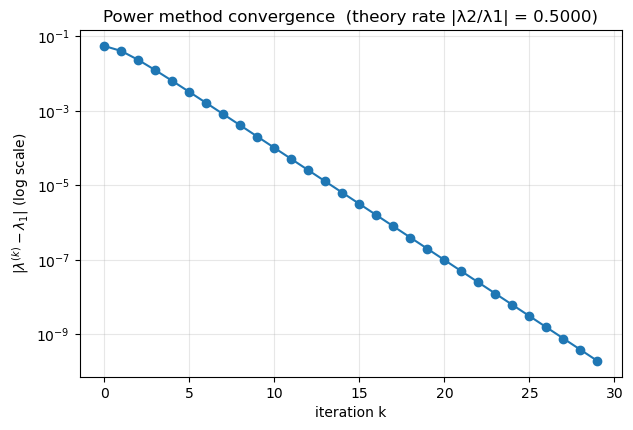

power method eigenvalue : 6.000000000096344
numpy eigenvalues       : [6. 3. 3.]


In [23]:
def power_method(A, x0, tol=1e-10, max_iter=200):
    x = x0 / np.linalg.norm(x0)
    lam = 0.0
    trace = []
    for _ in range(max_iter):
        x_new = A @ x
        x_new = x_new / np.linalg.norm(x_new)
        lam_new = x_new @ A @ x_new
        trace.append(lam_new)
        if abs(lam_new - lam) < tol:
            return lam_new, x_new, trace
        x, lam = x_new, lam_new
    return lam, x, trace

A = np.array([[4.0, 1.0, 1.0], [2.0, 4.0, 1.0], [0.0, 1.0, 4.0]])
lam1, v1, trace = power_method(A, np.array([1.0, 1.0, 1.0]))

eigvals = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
ratio = eigvals[1] / eigvals[0]

lam_true = eigvals[0]
errors = [abs(l - lam_true) for l in trace]

plt.figure()
plt.semilogy(errors[:-1], "o-")  # last error is ~0 by construction of the stopping test
plt.xlabel("iteration k")
plt.ylabel(r"$|\lambda^{(k)} - \lambda_1|$ (log scale)")
plt.title(f"Power method convergence  (theory rate |λ2/λ1| = {ratio:.4f})")
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("power method eigenvalue :", lam1)
print("numpy eigenvalues       :", np.sort(np.linalg.eigvals(A))[::-1])

## L7.2 Inverse power method

Applying the power method to $A^{-1}$ finds the eigenvalue of $A^{-1}$ of
largest modulus, i.e. the eigenvalue of $A$ of **smallest** modulus
(same eigenvectors, reciprocal eigenvalues) `[B, §12.1.2]`. In practice one
factorizes $A$ once (L2.2) and solves $A x^{(k+1)}=x^{(k)}$ at each step
instead of forming $A^{-1}$ explicitly; here we keep the explicit inverse
for clarity, consistent with L2's development.

In [24]:
def inverse_power_method(A, x0, tol=1e-10, max_iter=200):
    A_inv = np.linalg.inv(A)
    x = x0 / np.linalg.norm(x0)
    lam = 0.0
    for _ in range(max_iter):
        x_new = A_inv @ x
        x_new = x_new / np.linalg.norm(x_new)
        lam_new = x_new @ A @ x_new   # Rayleigh quotient w.r.t. the *original* A
        if abs(lam_new - lam) < tol:
            return lam_new, x_new
        x, lam = x_new, lam_new
    return lam, x

lam_min, v_min = inverse_power_method(A, np.array([1.0, 1.0, 1.0]))
print("smallest-modulus eigenvalue (inverse power) :", lam_min)
print("numpy eigenvalues                            :", np.sort(np.linalg.eigvals(A)))

smallest-modulus eigenvalue (inverse power) : 2.9999999999126876
numpy eigenvalues                            : [3. 3. 6.]


## L7.3 The QR algorithm

The basic (unshifted) **QR algorithm** iterates $A_0=A$,
$A_k=Q_kR_k$ (QR factorization, L4.2), $A_{k+1}=R_kQ_k$. Each $A_{k+1}$ is
orthogonally similar to $A_k$ (hence to $A$: same eigenvalues), and under
mild conditions (eigenvalues of distinct modulus) $A_k$ converges to
upper-triangular (Schur) form, revealing all eigenvalues on the diagonal
at once `[B, §12.1.4]`.

*Caveat.* This convergence-to-diagonal statement needs the eigenvalues to
be real and of distinct modulus. A real matrix with a complex-conjugate
pair of eigenvalues instead converges to a **real Schur form**: block
upper-triangular with a $2\times2$ block per complex pair, whose diagonal
entries are *not* individually eigenvalues. The demo below therefore uses
a matrix known to have three real, distinct eigenvalues.

In [25]:
def qr_algorithm(A, iterations=200):
    Ak = A.astype(float).copy()
    for _ in range(iterations):
        Q, R = np.linalg.qr(Ak)
        Ak = R @ Q
    return np.diag(Ak), Ak

A = np.array([[6, 2, 1], [2, 3, 1], [1, 1, 1]], dtype=float)  # symmetric => real eigenvalues
eigs_qr, A_final = qr_algorithm(A)
print("QR algorithm eigenvalue estimates:", np.sort(eigs_qr))
print("numpy eigenvalues                :", np.sort(np.linalg.eigvals(A)))

QR algorithm eigenvalue estimates: [0.578933 2.133074 7.287992]
numpy eigenvalues                : [0.578933 2.133074 7.287992]


# Bibliography

- G. Puppo, *Metodi Numerici*, lecture notes, Sapienza Università di Roma
  (chapters 1–7).
- A. Greenbaum and T. P. Chartier, *Numerical Methods: Design, Analysis,
  and Computer Implementation of Algorithms*, Princeton University Press,
  2012.
- L. N. Trefethen and D. Bau III, *Numerical Linear Algebra*, SIAM, 1997.
- G. H. Golub and C. F. Van Loan, *Matrix Computations*, 4th ed., Johns
  Hopkins University Press, 2013.
- A. Quarteroni, R. Sacco, F. Saleri, *Numerical Mathematics*, 2nd ed.,
  Springer, 2007.
- IEEE Std 754-2019, *IEEE Standard for Floating-Point Arithmetic*.

## Not covered here (out of scope for L1–L7)

Topics present in the sources above but outside chapters 1–7 of the course
notes — e.g. systems of nonlinear equations, spectral/Gauss quadrature,
boundary/initial value problems for ODEs and PDEs — are intentionally left
out to keep this notebook aligned with the L1–L7 syllabus; they are natural
candidates for a follow-up notebook (`[B, Ch. 10 §10.3, Ch. 11, Ch. 13-14]`).